# Contoh: Index Iklim untuk Data Grid (lat/lon)

Notebook ini mendemonstrasikan penggunaan package `rain_indices_pkg`
(`rain_indices`, `temp_indices`) pada data **grid spasial** (dims: time, lat, lon),
menggunakan data sintetis mirip output model iklim (mis. CMIP/RCM), termasuk
chunking dask untuk mensimulasikan dataset besar.

Alur:
1. Bangun `xr.Dataset` sintetis dims `(time, lat, lon)` untuk `pr`, `tasmax`, `tasmin`, `tas`.
2. Chunk dengan dask supaya mirip alur kerja data grid asli.
3. Hitung index curah hujan (`rain_indices`) dan index suhu (`temp_indices`).
4. Plot peta spasial salah satu index (mis. rata-rata `PRCPTOT` dan `TXx`).


In [1]:
import sys
from pathlib import Path

# Tambahkan folder src/ (satu tingkat di atas notebooks/) ke sys.path
SRC_PATH = "../src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))
print("src path terdaftar:", SRC_PATH)

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from indek_ekstrim import rain_indices, temp_indices

np.random.seed(7)

src path terdaftar: ../src


## 1. Bangun grid sintetis

Domain kecil (5 x 6) supaya notebook ringan dijalankan, tapi struktur
(dims + chunking dask) sama seperti dataset grid nyata.

In [2]:
lat = np.linspace(-8.0, -5.0, 5)     # contoh domain Jawa bagian selatan
lon = np.linspace(107.0, 112.0, 6)
dates = pd.date_range("2010-01-01", "2020-12-31", freq="D")

n_time, n_lat, n_lon = len(dates), len(lat), len(lon)
doy = dates.dayofyear.values.reshape(-1, 1, 1)

# --- Curah hujan (pr): satuan asli model biasanya kg m-2 s-1, uji convert_units() ---
is_wet_prob = 0.3 + 0.1 * np.sin(2 * np.pi * (doy - 300) / 365.25)   # musim hujan lebih basah
is_wet = np.random.rand(n_time, n_lat, n_lon) < is_wet_prob
amounts_mm_day = np.random.exponential(scale=15, size=(n_time, n_lat, n_lon))
pr_mm_day = np.where(is_wet, amounts_mm_day, 0.0)
pr_kg_m2_s1 = pr_mm_day / 86400.0   # balik ke kg/m2/s, biar convert_units() beneran dites

# --- Suhu (tasmax/tasmin/tas): satuan Kelvin, ada gradien lintang sederhana ---
lat_grid = lat.reshape(1, -1, 1)
seasonal = 4 * np.sin(2 * np.pi * (doy - 80) / 365.25)
lat_effect = -0.3 * lat_grid   # sedikit lebih hangat ke arah ekuator (lat makin negatif -> lebih hangat)

tasmax_c = 31 + seasonal + lat_effect + np.random.normal(0, 1.5, (n_time, n_lat, n_lon))
tasmin_c = 22 + seasonal + lat_effect + np.random.normal(0, 1.5, (n_time, n_lat, n_lon))
tas_c    = (tasmax_c + tasmin_c) / 2

ds_grid = xr.Dataset(
    {
        "pr":     (["time", "lat", "lon"], pr_kg_m2_s1, {"units": "kg m-2 s-1"}),
        "tasmax": (["time", "lat", "lon"], tasmax_c + 273.15, {"units": "K"}),
        "tasmin": (["time", "lat", "lon"], tasmin_c + 273.15, {"units": "K"}),
        "tas":    (["time", "lat", "lon"], tas_c + 273.15, {"units": "K"}),
    },
    coords={"time": dates, "lat": lat, "lon": lon},
)
ds_grid

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 4018, lat: 5, lon: 6)
Coordinates:
  * time     (time) datetime64[us] 32kB 2010-01-01 2010-01-02 ... 2020-12-31
  * lat      (lat) float64 40B -8.0 -7.25 -6.5 -5.75 -5.0
  * lon      (lon) float64 48B 107.0 108.0 109.0 110.0 111.0 112.0
Data variables:
    pr       (time, lat, lon) float64 964kB 0.0001434 0.0 0.0 ... 0.0 0.0 0.0
    tasmax   (time, lat, lon) float64 964kB 300.9 304.1 301.4 ... 301.3 300.8
    tasmin   (time, lat, lon) float64 964kB 290.1 294.5 293.6 ... 292.9 292.3
    tas      (time, lat, lon) float64 964kB 295.5 299.3 297.5 ... 297.1 296.6

## 2. Chunk dengan dask (mensimulasikan dataset besar / lazy compute)

In [3]:
ds_grid = ds_grid.chunk({"time": 365, "lat": -1, "lon": -1})
ds_grid

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 4018, lat: 5, lon: 6)
Coordinates:
  * time     (time) datetime64[us] 32kB 2010-01-01 2010-01-02 ... 2020-12-31
  * lat      (lat) float64 40B -8.0 -7.25 -6.5 -5.75 -5.0
  * lon      (lon) float64 48B 107.0 108.0 109.0 110.0 111.0 112.0
Data variables:
    pr       (time, lat, lon) float64 964kB dask.array<chunksize=(365, 5, 6), meta=np.ndarray>
    tasmax   (time, lat, lon) float64 964kB dask.array<chunksize=(365, 5, 6), meta=np.ndarray>
    tasmin   (time, lat, lon) float64 964kB dask.array<chunksize=(365, 5, 6), meta=np.ndarray>
    tas      (time, lat, lon) float64 964kB dask.array<chunksize=(365, 5, 6), meta=np.ndarray>

## 3. Hitung index curah hujan (`rain_indices`)

In [4]:
rain_result = rain_indices(
    ds_grid,
    varname="pr",
    slice_mode="ANN",
    verbose=True,
)
rain_result

[rain_indices] building graph: RX1DAY
[rain_indices] building graph: RX3DAY
[rain_indices] building graph: RX5DAY
[rain_indices] building graph: RX7DAY
[rain_indices] building graph: RX10DAY
[rain_indices] building graph: HH
[rain_indices] building graph: HH20MM
[rain_indices] building graph: HH50MM
[rain_indices] building graph: HH100MM
[rain_indices] building graph: HH150MM
[rain_indices] building graph: FH20MM
[rain_indices] building graph: FH50MM
[rain_indices] building graph: FH100MM
[rain_indices] building graph: FH150MM
[rain_indices] building graph: PRCPTOT
[rain_indices] building graph: CDD
[rain_indices] building graph: CWD
[rain_indices] building graph: SDII
[rain_indices] building graph: R95P
[rain_indices] building graph: R99P
[rain_indices] building graph: R95PTOT
[rain_indices] building graph: R99PTOT
[rain_indices] computing 22 indices in parallel...


<xarray.Dataset> Size: 58kB
Dimensions:  (lat: 5, lon: 6, year: 11)
Coordinates:
  * lat      (lat) float64 40B -8.0 -7.25 -6.5 -5.75 -5.0
  * lon      (lon) float64 48B 107.0 108.0 109.0 110.0 111.0 112.0
  * year     (year) int64 88B 2010 2011 2012 2013 2014 ... 2017 2018 2019 2020
Data variables: (12/22)
    RX1DAY   (year, lat, lon) float64 3kB 68.96 59.49 61.33 ... 97.75 69.91
    RX3DAY   (year, lat, lon) float64 3kB 118.1 76.35 117.1 ... 125.7 111.7
    RX5DAY   (year, lat, lon) float64 3kB 130.3 105.7 122.4 ... 140.4 123.2
    RX7DAY   (year, lat, lon) float64 3kB 176.6 133.3 138.0 ... 153.5 165.5
    RX10DAY  (year, lat, lon) float64 3kB 199.1 146.1 142.1 ... 162.2 177.0
    HH       (year, lat, lon) float64 3kB 111.0 88.0 101.0 ... 91.0 95.0 95.0
    ...       ...
    CWD      (year, lat, lon) float64 3kB 5.0 4.0 5.0 3.0 ... 3.0 4.0 4.0 4.0
    SDII     (year, lat, lon) float64 3kB 16.67 15.16 14.57 ... 15.77 14.66
    R95P     (year, lat, lon) float64 3kB 324.5 244.3 269.2 ... 310.9 261.7
    R99P     (year, lat, lon) float64 3kB 128.5 59.49 61.33 ... 97.75 69.91
    R95PTOT  (year, lat, lon) float64 3kB 17.54 18.32 18.3 ... 21.72 20.75 18.78
    R99PTOT  (year, lat, lon) float64 3kB 6.946 4.46 4.169 ... 5.669 6.524 5.019

## 4. Hitung index suhu (`temp_indices`)

In [8]:
temp_result = temp_indices(
    ds_grid,
    slice_mode="ME",
    verbose=True,
)
temp_result

[temp_indices] preparing variable: tasmax
[temp_indices] building graph: TXx (var=['tasmax'])
[temp_indices] building graph: TXn (var=['tasmax'])
[temp_indices] building graph: TXm (var=['tasmax'])
[temp_indices] preparing variable: tasmin
[temp_indices] building graph: TNx (var=['tasmin'])
[temp_indices] building graph: TNn (var=['tasmin'])
[temp_indices] building graph: TNm (var=['tasmin'])
[temp_indices] preparing variable: tas
[temp_indices] building graph: TMx (var=['tas'])
[temp_indices] building graph: TMn (var=['tas'])
[temp_indices] building graph: TMm (var=['tas'])
[temp_indices] building graph: FD (var=['tasmin'])
[temp_indices] building graph: ID (var=['tasmax'])
[temp_indices] building graph: SU (var=['tasmax'])
[temp_indices] building graph: TR (var=['tasmin'])
[temp_indices] building graph: DTR (var=['tasmax', 'tasmin'])
[temp_indices] building graph: ETR (var=['tasmax', 'tasmin'])
[temp_indices] computing 15 indices in parallel...


<xarray.Dataset> Size: 476kB
Dimensions:           (lat: 5, lon: 6, __resample_dim__: 132)
Coordinates:
  * lat               (lat) float64 40B -8.0 -7.25 -6.5 -5.75 -5.0
  * lon               (lon) float64 48B 107.0 108.0 109.0 110.0 111.0 112.0
  * __resample_dim__  (__resample_dim__) datetime64[us] 1kB 2010-01-31 ... 20...
Data variables: (12/15)
    TXx               (__resample_dim__, lat, lon) float64 32kB 34.42 ... 31.35
    TXn               (__resample_dim__, lat, lon) float64 32kB 27.72 ... 24.32
    TXm               (__resample_dim__, lat, lon) float64 32kB 30.16 ... 28.34
    TNx               (__resample_dim__, lat, lon) float64 32kB 23.84 ... 22.19
    TNn               (__resample_dim__, lat, lon) float64 32kB 16.97 ... 17.08
    TNm               (__resample_dim__, lat, lon) float64 32kB 20.88 ... 19.67
    ...                ...
    FD                (__resample_dim__, lat, lon) float64 32kB 0.0 0.0 ... 0.0
    ID                (__resample_dim__, lat, lon) float64 32kB 0.0 0.0 ... 0.0
    SU                (__resample_dim__, lat, lon) float64 32kB 31.0 ... 30.0
    TR                (__resample_dim__, lat, lon) float64 32kB 19.0 ... 15.0
    DTR               (__resample_dim__, lat, lon) float64 32kB 9.278 ... 8.664
    ETR               (__resample_dim__, lat, lon) float64 32kB 17.45 ... 14.27

## 5. Peta spasial: rata-rata index sepanjang tahun

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

rain_result["PRCPTOT"].mean(dim="year").plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Rata-rata PRCPTOT (mm/tahun)")

temp_result["TXx"].mean(dim="year").plot(ax=axes[1], cmap="OrRd")
axes[1].set_title("Rata-rata TXx (°C)")

plt.tight_layout()
plt.show()

## 6. Time series rata-rata spasial (domain-averaged) per tahun

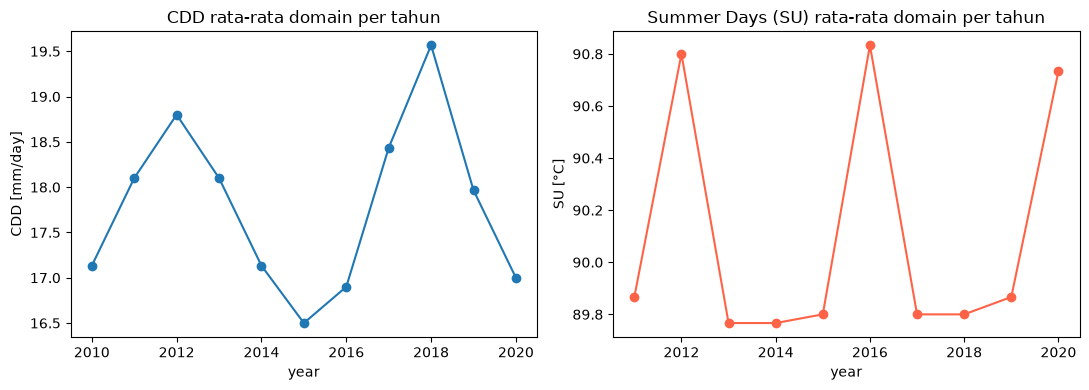

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

rain_result["CDD"].mean(dim=["lat","lon"]).plot(ax=axes[0], marker="o")
axes[0].set_title("CDD rata-rata domain per tahun")

temp_result["SU"].mean(dim=["lat","lon"]).plot(ax=axes[1], marker="o", color="tomato")
axes[1].set_title("Summer Days (SU) rata-rata domain per tahun")

plt.tight_layout()
plt.show()

## 7. Simpan hasil ke NetCDF (opsional)

```python
rain_result.to_netcdf("rain_indices_grid.nc")
temp_result.to_netcdf("temp_indices_grid.nc")
```
